# Caching Schemes Experimentation

## Experiment Hyperparameters

In [59]:
CACHE_SIZE = 5
MAX_NODES = 120
MIN_NODES = 20
ITERS_PER_GRAPH = 30
ITERS_PER_SIZE = 100

## Experiment

### Methodology

1. We will use the following caching schemes:
    - LRU
    - LFU
    - Weighted LFU
    - PageRank
    - Weighted PageRank
    - InDegree
    - Weighted InDegree
2. Our methodology for generating a 'repos' with `n` files is as follows:
    - We will generate a random graph with `n` nodes
    - Each node will represent a file, whose size will be randomly generated
    - The larger the file, the more dependencies it likely has
    - We will generate a random number of dependencies for each file and it connect it to random files
3. We will generate a random *distribution* of queries based on the following method:
    - The more dependencies a file has, the more likely it is to be queried
    - The larger the file, the more likely it is to be queried

In [60]:
import networkx as nx
import numpy as np
import random

def random_graph(num_files=100):
    # Create a directed acyclic graph
    G = nx.DiGraph()

    # Generate file sizes using a lognormal distribution
    file_sizes = np.random.lognormal(mean=5, sigma=1, size=num_files)
    # Add nodes with file size attributes
    for i in range(num_files):
        G.add_node(i, size=file_sizes[i])

    # Add edges to simulate dependencies, preferring smaller files to depend on larger ones
    for i in range(num_files):
        num_dependencies = np.random.poisson(2)  # Average number of dependencies
        if i > 0:
            # Sort potential dependencies by size in descending order (larger files first)
            potential_dependencies = sorted(range(i), key=lambda x: file_sizes[x], reverse=True)
            # Bias selection towards larger files by taking the top candidates
            dependencies = np.random.choice(
                potential_dependencies,  # Limit to top 10 largest files
                size=min(num_dependencies, i),
                replace=False
            )
            for dep in dependencies:
                G.add_edge(dep, i)

    return G

def generate_error_pdf(graph: nx.DiGraph, error_model='linear'):
    # Step 1: Extract file sizes from graph node attributes
    file_sizes = nx.get_node_attributes(graph, 'size')
    max_file_size = max(file_sizes.values())
    out_degrees = graph.out_degree()
    max_out_degree = max([out_degrees[node] for node in graph.nodes()])
    complexity = {node: random.uniform(0, 1) for node in file_sizes.keys()}

    # Step 2: Apply the error model to file sizes
    if error_model == 'linear':
        error_weights = {node: 0.2*complexity[node] + 0.2*size/max_file_size + 0.6*out_degrees[node]/max_out_degree for node, size in file_sizes.items()}
    elif error_model == 'random':
        error_weights = {node: complexity[node] for node in file_sizes.keys()}
    else:
        raise ValueError("Unsupported error model")

    # Step 3: Normalize weights to create a probability distribution
    total_weight = sum(error_weights.values())
    pdf = {node: weight / total_weight for node, weight in error_weights.items()}

    return pdf

In [61]:
from utils.cache import Cache
import networkx as nx
import random
from tqdm import tqdm
from collections import defaultdict

caches: list[Cache] = [CacheType(CACHE_SIZE) for CacheType in Cache.__subclasses__()]

cache_hit_rate = [defaultdict(int) for _ in range(len(caches))] # cache_hit_rate[i][j] = avg hit rate for cache i, graph size j

for n in tqdm(range(MIN_NODES, MAX_NODES+1)):  # Loop over graph sizes
    local_hit_rates = [[] for _ in range(len(caches))] # local_hit_rates[i] = hit rates for cache i
    for _ in range(ITERS_PER_SIZE):  # Generate random graphs for each size
        G = random_graph(n)
        pdf = generate_error_pdf(G)
        for cache in caches:
            cache.initialize(G)
        for _ in range(ITERS_PER_GRAPH):  # Randomly select nodes to test
            u = random.choices(list(G.nodes()), weights=[pdf[node] for node in G.nodes()])[0]
            # Get dependencies of `u`
            dependencies = set(G[u]) | {u}
            # Update cache based on dependencies
            for dep in dependencies:
                for cache in caches:
                    cache.query(dep)
        for i, cache in enumerate(caches):
            local_hit_rates[i].append(cache.hit_rate())
    for i in range(len(caches)):
        cache_hit_rate[i][n] = np.mean(local_hit_rates[i])

100%|██████████| 101/101 [01:04<00:00,  1.56it/s]


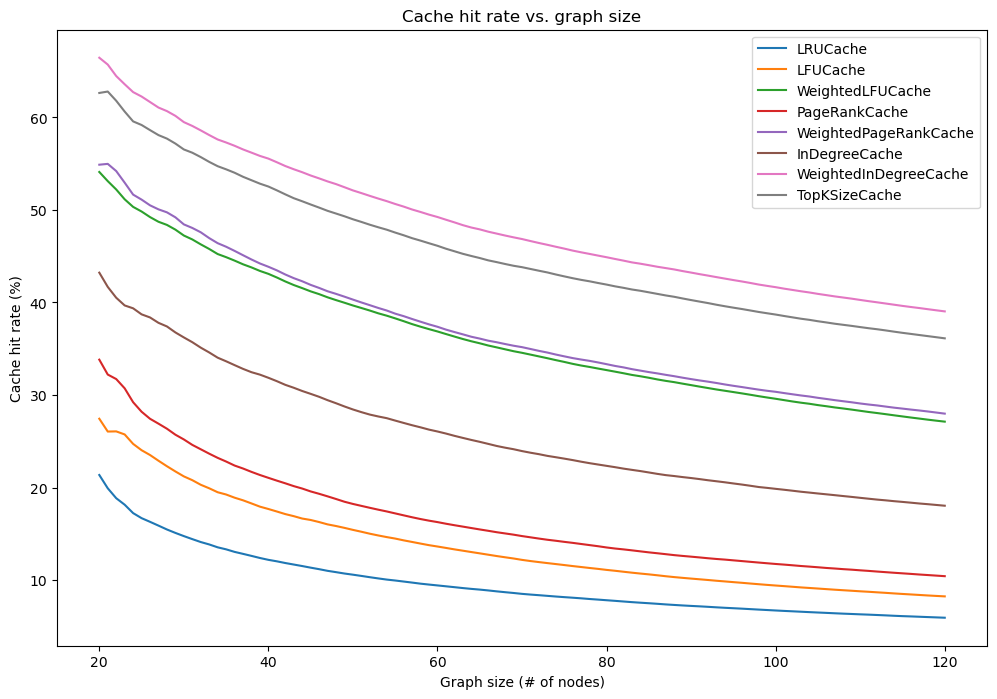

LRUCache: 9.64%
LFUCache: 13.73%
WeightedLFUCache: 36.31%
PageRankCache: 16.59%
WeightedPageRankCache: 37.10%
InDegreeCache: 25.86%
WeightedInDegreeCache: 48.56%
TopKSizeCache: 45.55%


In [62]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 8))
for i, cache in enumerate(caches):
    plt.plot(cache_hit_rate[i].keys(), [x*100 for x in cache_hit_rate[i].values()], label=cache.__class__.__name__)
plt.xlabel('Graph size (# of nodes)')
plt.ylabel('Cache hit rate (%)')
plt.legend()
plt.title('Cache hit rate vs. graph size')
plt.show()

# Print average hit rates for each cache
for i, cache in enumerate(caches):
    print(f'{cache.__class__.__name__}: {np.mean(list(cache_hit_rate[i].values()))*100:.2f}%')